# "VeriVoice" Security System

### The Scenario
You are working on "VeriVoice," a security system designed to detect AI-generated voice cloning in phone calls.


Instead of analyzing raw audio waves, a pre-processing neural network converts the audio spectrogram into a 5-dimensional feature embedding (X). These 5 numbers represent abstract features like "pitch micro-tremors," "breath cadence," "background noise consistency," etc.


Your final classification layer is a simple linear model without a bias term. It classifies the embedding using a learned weight vector W:

### y=sign(WTX)=sign(w1 x1 +w2 x2 +w3 x3 +w4 x4 +w5 x5 )

### Score >0: Classified as Human Voice (+1)

### Score <0: Classified as AI Voice (-1)


The Model Weights (W): Your model has learned the following weights for the 5 dimensions:


### W=[2,−3,1,4,−2]


### Knowledge Check
**Question 1:** A suspicious phone call is processed, generating the following embedding vector X:

### X=[3,2,−1,−2,5]

Based on the calculation, how does the system classify this call?

A) Human Voice (+1)

B) AI Voice (-1)

C) Undecided (Score is 0)

D) Error in dimensions


Answer = (B) y = (2*3)+(-3*2)+(1*-1)+(4*-2)+(-2*5) = -19, therefore it is an AI voice.

### Knowledge Check
**Question 2:** Look at the embedding X from Question 1 again. The 4th feature in the embedding is x4 =−2.If purely due to a sensor glitch, this feature had been recorded as a different value, what’s the tolerance range of the noise in x4 until the decision gets flipped?(Assume all other features remain unchanged).


A) x4  must be greater than 2.75

B) x4  must be greater than 4.0

C) x4  must be less than -5.0

D) It is impossible to flip the decision by changing only one feature.


Answer = (A), the inequality for not flipping is 4x-11<0, or x<2.75. Hence x4 can tolerate noises upto 2.75 but anything above it will give wrong results.

### Knowledge Check
**Question 3:** Geometrically, what does the calculation WTX tell us about the relationship between the Weight Vector (W) and the Embedding Vector (X)?

A) It calculates the Euclidean distance between the weight vector and the audio embedding.

B) The sign tells us if the angle between W and X is acute (<90∘) or obtuse (>90∘).

C) It determines if the vectors are parallel to each other.

D) It projects the 5D data onto a 2D plane for visualization.



Answer = (B); as the thing we are doing is essentially an inner product of 2 vectors W and X. This is mathematically similar to finding the angle (cos(θ)) and greater than or less than 0 implies angle being obtuse or acute.

### Code Walkthrough

**Question 4:** Instead of 5 dimensions, now play around 100 dimensions. Try changing the sign of each value in x and observe the result.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Set a seed for reproducibility so students get the same results
np.random.seed(42)

In [4]:
# 1. Define dimensions
dimensions = 100

In [5]:
# 2. Generate Weight Vector (W)
# These represent the importance the model gives to each of the 100 features
W = np.random.uniform(-1, 1, dimensions)
print(W.shape)

(100,)


In [11]:
# 3. Generate Feature Embedding (X)
# These represent the 100 abstract characteristics extracted from the audio spectrogram
X = np.random.uniform(-1, 1, dimensions)
print(X.shape)

(100,)


In [7]:
print(f"Successfully generated W and X with {dimensions} features each.")
print(f"First 5 weights: {W[:5]}")

Successfully generated W and X with 100 features each.
First 5 weights: [-0.25091976  0.90142861  0.46398788  0.19731697 -0.68796272]


In [8]:
# 4. # The 'Dot Product' is the sum of (w1*x1 + w2*x2 ... + wn*xn)
# It measures the alignment between our features and our learned weights
score = np.dot(W, X)

In [9]:
# 5. The sign function: If score is positive -> 1, if negative -> -1
# In this model, there is no 'bias' term, so the boundary passes through the origin
prediction = 1 if score > 0 else -1
result_text = "HUMAN VOICE (+1)" if prediction == 1 else "AI VOICE (-1)"

print(f"Model Calculation Complete.")
print(f"-------------------------------")
print(f"Total Weighted Score: {score:.4f}")
print(f"Classification      : {result_text}")

Model Calculation Complete.
-------------------------------
Total Weighted Score: -1.1493
Classification      : AI VOICE (-1)


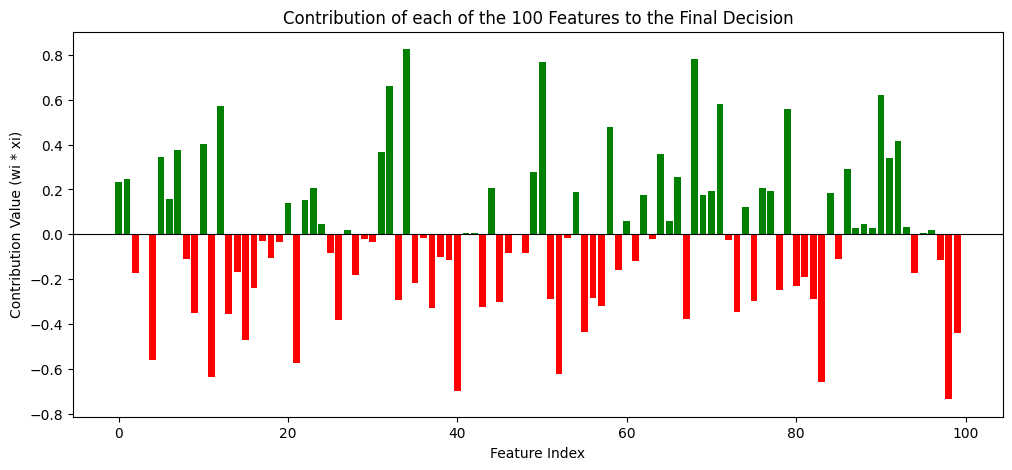

Green bars represent features that pushed the model toward a 'Human' classification.
Red bars represent features that pushed the model toward an 'AI' classification.


In [10]:
# 6. # Multiply W and X element-wise to see the 'contribution' of each feature
# Some features will have a positive impact, others a negative impact
contributions = W * X

plt.figure(figsize=(12, 5))
plt.bar(range(dimensions), contributions, color=['green' if c > 0 else 'red' for c in contributions])
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Contribution of each of the 100 Features to the Final Decision")
plt.xlabel("Feature Index")
plt.ylabel("Contribution Value (wi * xi)")
plt.show()

print("Green bars represent features that pushed the model toward a 'Human' classification.")
print("Red bars represent features that pushed the model toward an 'AI' classification.")

Model Calculation Complete.
-------------------------------
Total Weighted Score: 1.5115
Classification      : HUMAN VOICE (+1)


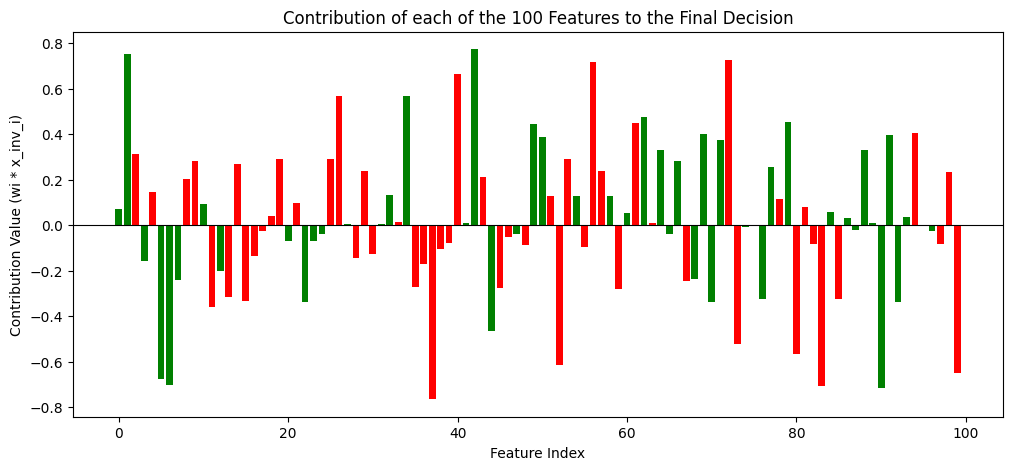

Green bars represent features that pushed the model toward a 'Human' classification.
Red bars represent features that pushed the model toward an 'AI' classification.


In [13]:
X_inv = -X
score_inv = np.dot(W, X_inv)

prediction = 1 if score_inv > 0 else -1
result_inv_text = "HUMAN VOICE (+1)" if prediction == 1 else "AI VOICE (-1)"

print(f"Model Calculation Complete.")
print(f"-------------------------------")
print(f"Total Weighted Score: {score_inv:.4f}")
print(f"Classification      : {result_inv_text}")

contributions_inv = W * X_inv

plt.figure(figsize=(12, 5))
plt.bar(range(dimensions), contributions_inv, color=['green' if c > 0 else 'red' for c in contributions])
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Contribution of each of the 100 Features to the Final Decision")
plt.xlabel("Feature Index")
plt.ylabel("Contribution Value (wi * x_inv_i)")
plt.show()

print("Green bars represent features that pushed the model toward a 'Human' classification.")
print("Red bars represent features that pushed the model toward an 'AI' classification.")